In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive


drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Abschlussarbeit_Projekt/data'

TARGET_COL = 'anomaly'

def load_data_complete(base_path):

    print("Start des TOTAL-Ladevorgangs")
    print("- Lesen von CSV-Dateien..")
    df_train = pd.read_csv(os.path.join(base_path, 'train.csv'), parse_dates=['timestamp'])
    df_meta = pd.read_csv(os.path.join(base_path, 'metadata.csv'))
    df_weather = pd.read_csv(os.path.join(base_path, 'weather.csv'), parse_dates=['timestamp'])

    if 'building_id_kaggle' in df_meta.columns:
        df_meta = df_meta.rename(columns={'building_id': 'building_original_name'})
        df_meta = df_meta.rename(columns={'building_id_kaggle': 'building_id'})

    print("(Panther -> 0)")

    site_map = dict(zip(df_meta['site_id'], df_meta['site_id_kaggle']))
    df_weather['site_id'] = df_weather['site_id'].map(site_map)
    df_train['building_id'] = df_train['building_id'].astype('Int64')
    df_meta['building_id'] = pd.to_numeric(df_meta['building_id'], errors='coerce').astype('Int64')

    df_meta['site_id'] = df_meta['site_id_kaggle'].astype('Int64')
    df_weather['site_id'] = pd.to_numeric(df_weather['site_id'], errors='coerce').astype('Int64')

    print("- Fusion 1: Train + Informationen zu Gebäuden..")
    df_merged = df_train.merge(df_meta, on='building_id', how='left')

    print("- Fusion 2 : + Wetter..")
    df_merged = df_merged.merge(df_weather, on=['site_id', 'timestamp'], how='left')

    return df_merged

try:
    df = load_data_complete(BASE_PATH)

    print("\n" + "="*50)
    print("ERGEBNIS DES LADEZUSTANDS (Data Loading Results)")
    print("="*50)
    print(f"Größe des Datensatzes (Shape) : {df.shape}")

    print("\n-1. Analyse der Zielvariable (Labels) -")

    if TARGET_COL in df.columns:
        counts = df[TARGET_COL].value_counts()
        pct = df[TARGET_COL].value_counts(normalize=True) * 100
        print(f"Colonne '{TARGET_COL}' gefunden.")
        print(f"   -> Normal (0)   : {counts.get(0, 0)} Einträge ({pct.get(0, 0):.2f}%)")
        print(f"   -> Anomalie (1) : {counts.get(1, 0)} Einträge ({pct.get(1, 0):.2f}%)")

        if pct.get(1, 0) < 0.01:
            print("Sehr wenige Anomalien (<0.01%)!")
    else:
        print(f" FEHLER: Die Spalte '{TARGET_COL}' existiert nicht!")
        print(f"   Verfügbare Spalten: {list(df.columns)}")

    print("\n- 2. Analyse auf Duplikate -")

    dups = df.duplicated(subset=['building_id', 'timestamp']).sum()
    if dups > 0:
        print(f" ACHTUNG: {dups} Duplikate (building_id + timestamp) gefunden.")

    else:
        print("Keine zeitlichen Duplikate gefunden.")

    print("\n-3. Fehlende Daten (Missing Values) ---")
    missing_sqm = df['sqm'].isnull().mean() * 100
    missing_temp = df['airTemperature'].isnull().mean() * 100

    print(f"Fehlende 'sqm' (Fläche)       : {missing_sqm:.2f}% (Erwartet: 0.00%)")
    print(f"Fehlende 'airTemperature'     : {missing_temp:.2f}% (Sollte gering sein)")

    print("\n" + "-"*50)
    if missing_temp < 10 and (TARGET_COL in df.columns):
        print("Datensatz ist bereit für die Analyse!")
    else:
        print("Probleme mit den Daten (Fehlende Labels oder zu viele N/A).")

except Exception as e:
    print(f"\nERROR:\n{e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Start des TOTAL-Ladevorgangs
- Lesen von CSV-Dateien..
(Panther -> 0)
- Fusion 1: Train + Informationen zu Gebäuden..
- Fusion 2 : + Wetter..

ERGEBNIS DES LADEZUSTANDS (Data Loading Results)
Größe des Datensatzes (Shape) : (1749494, 43)

-1. Analyse der Zielvariable (Labels) -
Colonne 'anomaly' gefunden.
   -> Normal (0)   : 1712198 Einträge (97.87%)
   -> Anomalie (1) : 37296 Einträge (2.13%)

- 2. Analyse auf Duplikate -
Keine zeitlichen Duplikate gefunden.

-3. Fehlende Daten (Missing Values) ---
Fehlende 'sqm' (Fläche)       : 0.00% (Erwartet: 0.00%)
Fehlende 'airTemperature'     : 0.15% (Sollte gering sein)

--------------------------------------------------
Datensatz ist bereit für die Analyse!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
print("-" * 55)

start_date = df['timestamp'].min()
end_date = df['timestamp'].max()
duration = end_date - start_date
print(f"1. Zeitraum: Von {start_date} bis {end_date}")
print(f"   (Gesamtdauer in : {duration.days} Tagen)")

nb_buildings = df['building_id'].nunique()
print(f"2. Anzahl der einzelnen Smart Meter : {nb_buildings}")

print("3. Top 5 der Gebäudetypen :")
print(df['primaryspaceusage'].value_counts().head(5))

if 'anomaly' in df.columns:
    nb_anomalies = df['anomaly'].sum()
    perc_anomalies = (nb_anomalies / len(df)) * 100
    print(f"4. Kennzeichnete Anomalien: {nb_anomalies} (das sind {perc_anomalies:.2f}% des Datensatzes)")
else:
    print("4. Spalte „Anomalie“ noch nicht geladen (wird später angezeigt).")

print("-" * 50)

-------------------------------------------------------
1. Zeitraum: Von 2016-01-01 00:00:00 bis 2016-12-31 23:00:00
   (Gesamtdauer in : 365 Tagen)
2. Anzahl der einzelnen Smart Meter : 200
3. Top 5 der Gebäudetypen :
primaryspaceusage
Education                        700790
Office                           542577
Entertainment/public assembly    200345
Lodging/residential              114050
Public services                   61461
Name: count, dtype: int64
4. Kennzeichnete Anomalien: 37296 (das sind 2.13% des Datensatzes)
--------------------------------------------------


ERSTELLUNG DES PIE CHART.


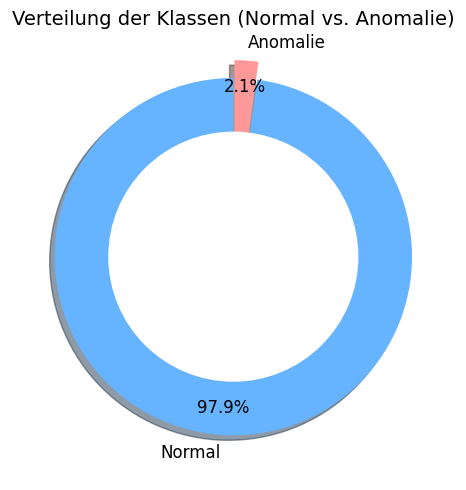

Bild gespeichert : analysis_images/class_balance.png


In [ ]:
import matplotlib.pyplot as plt
import os

if not os.path.exists('analysis_images'):
    os.makedirs('analysis_images')

print("ERSTELLUNG DES PIE CHART.")

if 'df' in locals():
    # Comptage
    counts = df['anomaly'].value_counts()

    # Configuration
    labels = ['Normal', 'Anomalie']
    sizes = [counts[0], counts[1]]
    colors = ['#66b3ff', '#ff9999'] # Bleu doux, Rouge alerte
    explode = (0, 0.1)  # Décroche la part 'Anomalie'

    plt.figure(figsize=(5, 5))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, pctdistance=0.85, textprops={'fontsize': 12})

    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title("Verteilung der Klassen (Normal vs. Anomalie)", fontsize=14)
    plt.tight_layout()

    # Sauvegarde
    plt.savefig('analysis_images/class_balance.png', dpi=300)
    plt.show()
    print("Bild gespeichert : analysis_images/class_balance.png")
else:
    print("Fehler: Der Datensatz „df” wurde nicht geladen.")

In [ ]:

TARGET_NUM_BUILDINGS = 200

top_buildings = df['building_id'].value_counts().head(TARGET_NUM_BUILDINGS).index
df_final = df[df['building_id'].isin(top_buildings)].copy()

print("="*40)
print(f"AUSWAHL DES DATENSATZES : Top {TARGET_NUM_BUILDINGS} Gebäude")
print("="*40)
print(f"Original shape : {df.shape}")
print(f"Selected shape : {df_final.shape}")

df = df_final

AUSWAHL DES DATENSATZES : Top 200 Gebäude
Original shape : (1749494, 43)
Selected shape : (1749494, 43)


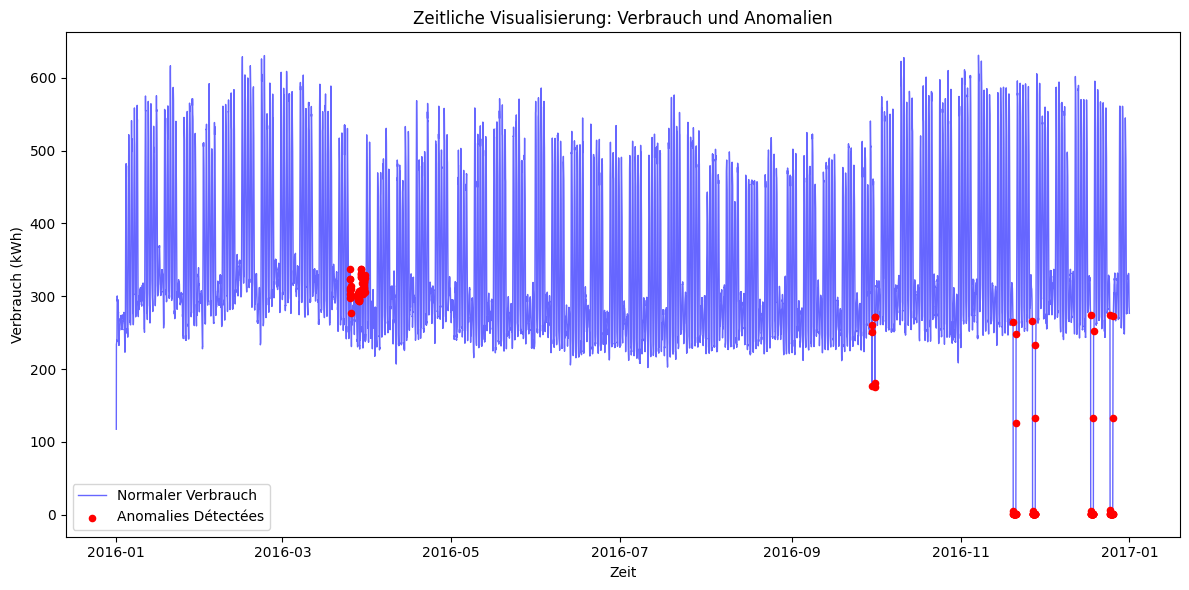

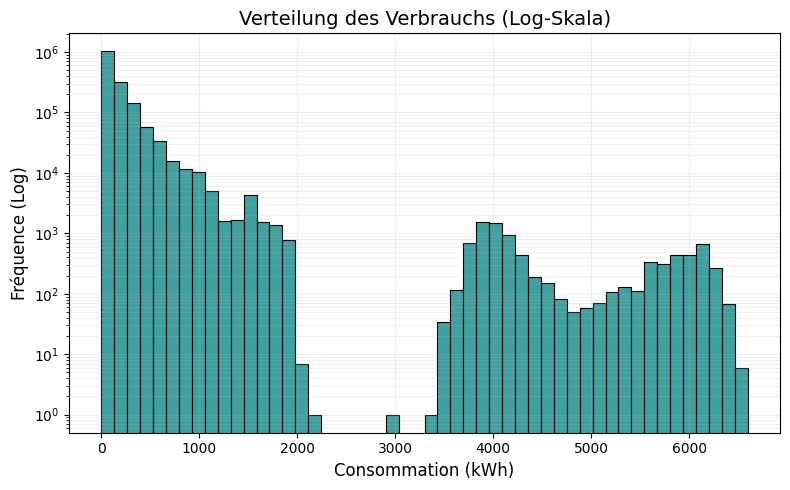

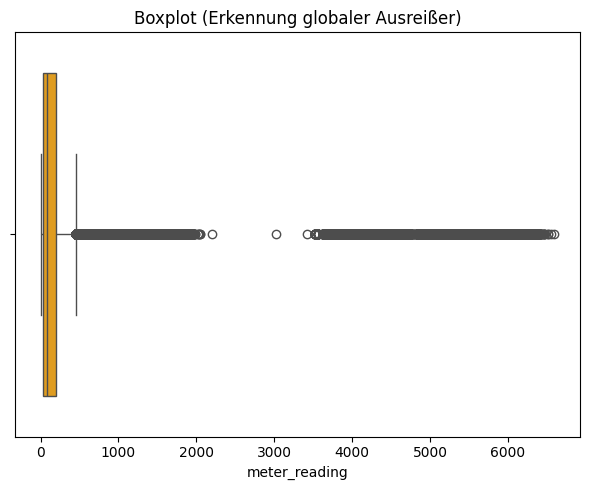

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os



if not os.path.exists('analysis_images'):
    os.makedirs('analysis_images')


plt.figure(figsize=(12, 6))
subset = df[df['building_id'] == 118].copy()
plt.plot(subset['timestamp'], subset['meter_reading'], label='Normaler Verbrauch', color='blue', alpha=0.6, linewidth=1)
anomalies = subset[subset['anomaly'] == 1]
plt.scatter(anomalies['timestamp'], anomalies['meter_reading'], color='red', label='Anomalies Détectées', zorder=5, s=20)
plt.title("Zeitliche Visualisierung: Verbrauch und Anomalien")
plt.xlabel("Zeit")
plt.ylabel("Verbrauch (kWh)")
plt.legend()
plt.tight_layout()
plt.savefig('analysis_images/time_series.png', dpi=300)
plt.show()



plt.figure(figsize=(8, 5))

sns.histplot(df['meter_reading'].dropna(), bins=50, kde=False, color='teal')

plt.yscale('log')
plt.title("Verteilung des Verbrauchs (Log-Skala)", fontsize=14)
plt.xlabel("Consommation (kWh)", fontsize=12)
plt.ylabel("Fréquence (Log)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig('analysis_images/histogram_corrected.png', dpi=300)
plt.show()


plt.figure(figsize=(6, 5))
sns.boxplot(x=df['meter_reading'], color='orange')
plt.title("Boxplot (Erkennung globaler Ausreißer)")
plt.xlabel("meter_reading")
plt.tight_layout()
plt.savefig('analysis_images/boxplot.png', dpi=300)
plt.show()


Vergleich
Durchschnittlich (Normal) : 181.08  |  Abweichung : 155200.75
Durchschnitt (Anomalie): 129.34  |  Abweichung : 220660.81


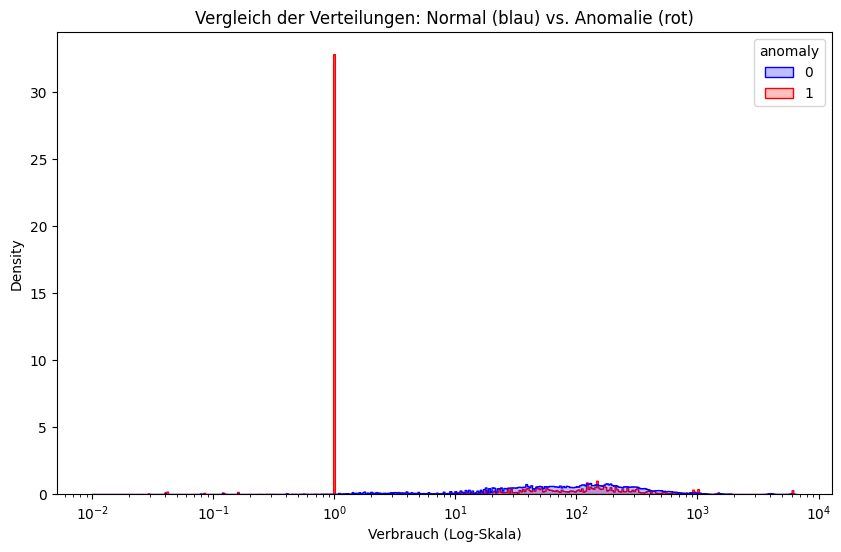

In [ ]:
normal_data = df[df['anomaly'] == 0]['meter_reading']
anom_data = df[df['anomaly'] == 1]['meter_reading']

print("Vergleich")
print(f"Durchschnittlich (Normal) : {normal_data.mean():.2f}  |  Abweichung : {normal_data.var():.2f}")

# Ligne corrigée ci-dessous : ajout de la variable, du guillemet et de la parenthèse
print(f"Durchschnitt (Anomalie): {anom_data.mean():.2f}  |  Abweichung : {anom_data.var():.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='meter_reading', hue='anomaly', element="step", stat="density", common_norm=False, log_scale=True, palette={0:'blue', 1:'red'})
plt.title("Vergleich der Verteilungen: Normal (blau) vs. Anomalie (rot)")
plt.xlabel("Verbrauch (Log-Skala)")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("- Beginn der Datenbereinigung -")
missing_ratio = df.isnull().mean() * 100
threshold = 50
cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()

print(f" Leere Spalten löschen (> {threshold}%) :")
print(cols_to_drop)
df = df.drop(columns=cols_to_drop)
df = df.sort_values(by=['building_id', 'timestamp'])

print("\nImputation fehlender Werte (lineare Interpolation).")

df['meter_reading'] = df.groupby('building_id')['meter_reading'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)
df['airTemperature'] = df.groupby('building_id')['airTemperature'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

print("\nErstellung zyklischer zeitlicher Merkmale (Sin/Cos).")

df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

df['day_of_week'] = df['timestamp'].dt.dayofweek

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7.0)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7.0)


print("\n" + "="*40)
remaining_nan = df.isnull().sum().sum()
if remaining_nan == 0:
    print(" Vollkommen sauberer Datensatz (0 NaN).")
    print(f"Final size : {df.shape}")
    print("   Neue Spalten (zyklisch): hour_sin, hour_cos usw..")
else:
    print(f"Fehler, es bleibt {remaining_nan} NaNs !")
    print(df.isnull().sum()[df.isnull().sum() > 0])

print("="*40)

- Beginn der Datenbereinigung -
 Leere Spalten löschen (> 50%) :
['hotwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating', 'precipDepth6HR']

Imputation fehlender Werte (lineare Interpolation).

Erstellung zyklischer zeitlicher Merkmale (Sin/Cos).

 Vollkommen sauberer Datensatz (0 NaN).
Final size : (1749494, 32)
   Neue Spalten (zyklisch): hour_sin, hour_cos usw..


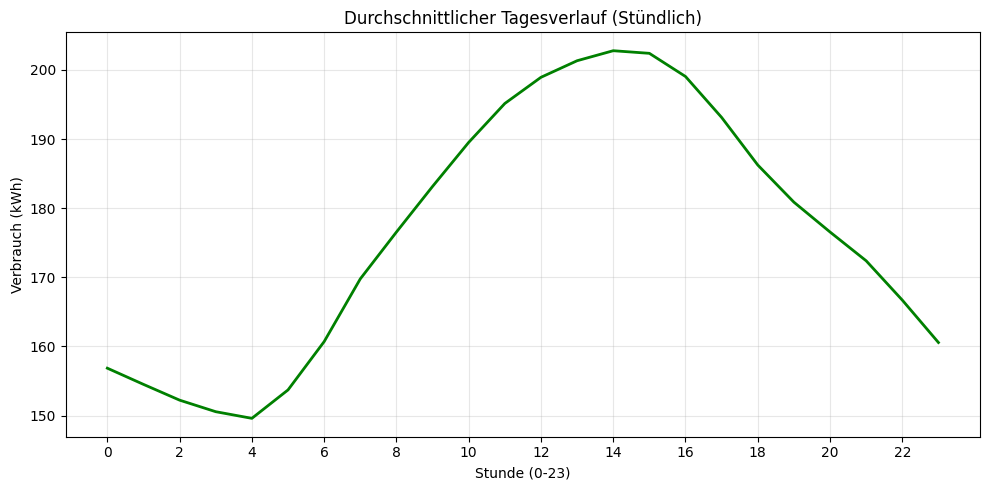

/tmp/ipython-input-274/419411678.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day_of_week', y='meter_reading', order=days_order, palette="Blues_d", errorbar=None)


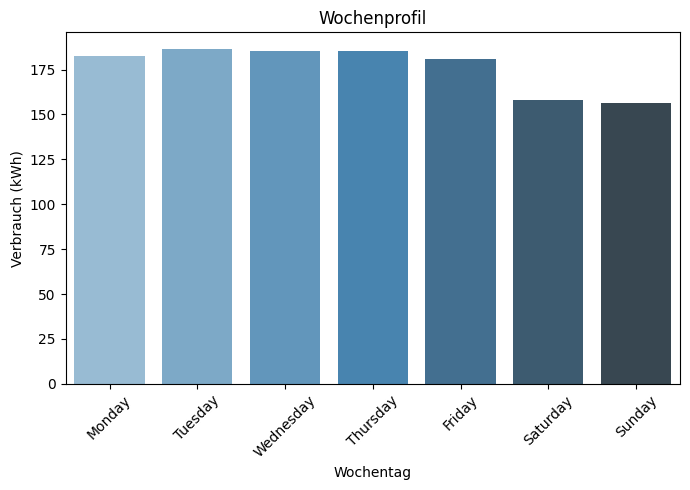

/tmp/ipython-input-274/419411678.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='month', y='meter_reading', order=months_order, palette="Reds_d", errorbar=None)


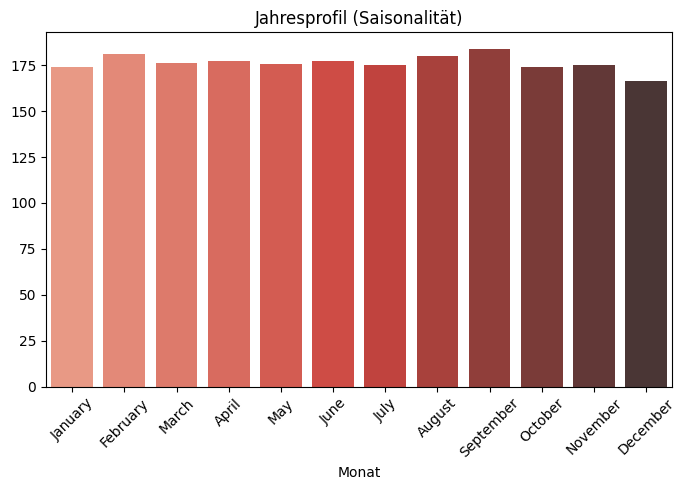

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd


if not os.path.exists('analysis_images'):
    os.makedirs('analysis_images')

if 'df' in locals():

    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.day_name()
    df['month'] = df['timestamp'].dt.month_name()


    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x='hour', y='meter_reading', color='green', errorbar=None, linewidth=2)
    plt.title("Durchschnittlicher Tagesverlauf (Stündlich)")
    plt.xlabel("Stunde (0-23)")
    plt.ylabel("Verbrauch (kWh)")
    plt.xticks(range(0, 24, 2))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig('analysis_images/pattern_daily.png', dpi=300)
    plt.show()

    plt.figure(figsize=(7, 5))
    days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    sns.barplot(data=df, x='day_of_week', y='meter_reading', order=days_order, palette="Blues_d", errorbar=None)
    plt.title("Wochenprofil")
    plt.xlabel("Wochentag")
    plt.ylabel("Verbrauch (kWh)")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig('analysis_images/pattern_weekly.png', dpi=300)
    plt.show()

    plt.figure(figsize=(7, 5))
    months_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
    sns.barplot(data=df, x='month', y='meter_reading', order=months_order, palette="Reds_d", errorbar=None)
    plt.title("Jahresprofil (Saisonalität)")
    plt.xlabel("Monat")
    plt.ylabel("")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig('analysis_images/pattern_yearly.png', dpi=300)
    plt.show()


else:
    print("KRITISCHER FEHLER: Die Variable „df” existiert nicht..")
    print("Lösung: Du musst die Zelle DATENLADEN (Schritt 1) ganz oben im Notizbuch neu starten.")

Start der Vorverarbeitung für das Gebäude 118...
   - Split Temporel : Train (7027 lignes) / Test (1757 lignes)
   - Stichtag : 2016-10-19 19:00:00

VORVERARBEITUNG ERFOLGREICH ABGESCHLOSSEN
Abmessungen Train : (7027, 4)
Abmessungen Test  : (1757, 4)
Verwendete Features : ['meter_reading', 'airTemperature', 'hour_sin', 'hour_cos']


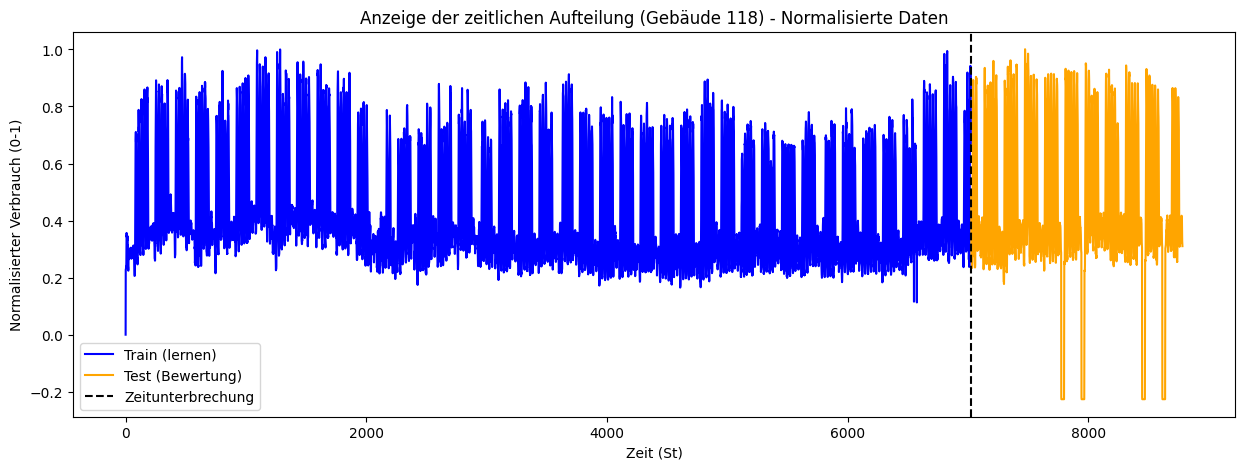

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

def preprocess_building_data(df_full, building_id, train_ratio=0.8):

    print(f"Start der Vorverarbeitung für das Gebäude {building_id}...")


    data = df_full[df_full['building_id'] == building_id].copy()
    data = data.sort_values('timestamp').reset_index(drop=True)

    data['meter_reading'] = data['meter_reading'].interpolate(method='linear', limit_direction='both')

    if 'airTemperature' in data.columns:
        data['airTemperature'] = data['airTemperature'].ffill().bfill()

    data['hour_sin'] = np.sin(2 * np.pi * data['timestamp'].dt.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data['timestamp'].dt.hour / 24)

    train_size = int(len(data) * train_ratio)

    train_df = data.iloc[:train_size].copy()
    test_df = data.iloc[train_size:].copy()

    print(f"   - Split Temporel : Train ({len(train_df)} lignes) / Test ({len(test_df)} lignes)")
    print(f"   - Stichtag : {data['timestamp'].iloc[train_size]}")

    feature_cols = ['meter_reading', 'airTemperature', 'hour_sin', 'hour_cos']

    scaler = MinMaxScaler(feature_range=(0, 1))

    scaler.fit(train_df[feature_cols])

    train_scaled = scaler.transform(train_df[feature_cols])
    test_scaled = scaler.transform(test_df[feature_cols])

    train_labels = train_df['anomaly'].values
    test_labels = test_df['anomaly'].values

    return train_scaled, test_labels, test_scaled, test_labels, scaler, feature_cols

target_id = 118

try:
    X_train, y_train, X_test, y_test, scaler_obj, features = preprocess_building_data(df, target_id)

    print("\nVORVERARBEITUNG ERFOLGREICH ABGESCHLOSSEN")
    print(f"Abmessungen Train : {X_train.shape}")
    print(f"Abmessungen Test  : {X_test.shape}")
    print(f"Verwendete Features : {features}")


    plt.figure(figsize=(15, 5))

    train_len = len(X_train)
    test_len = len(X_test)

    plt.plot(range(train_len), X_train[:, 0], label='Train (lernen)', color='blue')

    plt.plot(range(train_len, train_len + test_len), X_test[:, 0], label='Test (Bewertung)', color='orange')

    plt.axvline(x=train_len, color='black', linestyle='--', label='Zeitunterbrechung')
    plt.title(f"Anzeige der zeitlichen Aufteilung (Gebäude {target_id}) - Normalisierte Daten")
    plt.xlabel("Zeit (St)")
    plt.ylabel("Normalisierter Verbrauch (0-1)")
    plt.legend()
    plt.show()

except NameError:
    print(" Fehler: Die Variable „df” existiert nicht. Laden erneut starten (Schritt 1).")
except Exception as e:
    print(f"Fehler : {e}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


SEED = 42
np.random.seed(SEED)

def smart_building_selector(df, target_n=35):

    print(f"Suche nach {target_n} beste Kandidatengebäude..")
    quality_stats = []


    for bid, data in df.groupby('building_id'):
        missing_rate = data['meter_reading'].isnull().mean()
        zero_rate = (data['meter_reading'] == 0).mean()
        n_rows = len(data)

        if missing_rate < 0.20 and zero_rate < 0.20 and n_rows > 2000:
            quality_stats.append({
                'building_id': bid,
                'usage': data['primaryspaceusage'].iloc[0],
                'score': missing_rate + zero_rate
            })

    quality_df = pd.DataFrame(quality_stats)

    usage_counts = quality_df['usage'].value_counts(normalize=True)
    selected_ids = []

    print("\nAuswahl Stratifiziert :")
    for usage, proportion in usage_counts.items():
        n_to_take = max(1, int(round(proportion * target_n)))

        candidates = quality_df[quality_df['usage'] == usage].sort_values('score')
        best_candidates = candidates.head(n_to_take)['building_id'].tolist()
        selected_ids.extend(best_candidates)
        print(f"   - {usage:<35} : {len(best_candidates)} retenus")

    return list(set(selected_ids))

def preprocess_multi_buildings(df_full, building_ids, train_ratio=0.8):

    print(f"\n START DER VORVERARBEITUNG auf {len(building_ids)} gebäude...")

    all_train_X, all_test_X = [], []
    all_train_y, all_test_y = [], []

    feature_cols = [
        'meter_reading', 'airTemperature',
        'hour_sin', 'hour_cos',
        'day_sin', 'day_cos',
        'lag_1', 'lag_24',
        'rolling_mean_6h', 'rolling_std_6h'
    ]

    valid_count = 0

    for bid in building_ids:
        try:

            data = df_full[df_full['building_id'] == bid].copy()
            data = data.sort_values('timestamp').reset_index(drop=True)

            data['meter_reading'] = data['meter_reading'].interpolate(method='linear', limit_direction='both')
            if 'airTemperature' in data.columns:
                if data['airTemperature'].isnull().all():
                    data['airTemperature'] = 0
                else:
                    data['airTemperature'] = data['airTemperature'].ffill().bfill()


            data['hour_sin'] = np.sin(2 * np.pi * data['timestamp'].dt.hour / 24)
            data['hour_cos'] = np.cos(2 * np.pi * data['timestamp'].dt.hour / 24)

            data['day_of_week'] = data['timestamp'].dt.dayofweek
            data['day_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
            data['day_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)

            data['lag_1'] = data['meter_reading'].shift(1)
            data['lag_24'] = data['meter_reading'].shift(24)
            data['rolling_mean_6h'] = data['meter_reading'].rolling(window=6).mean()
            data['rolling_std_6h'] = data['meter_reading'].rolling(window=6).std()

            cols_to_keep = feature_cols + ['anomaly']
            data = data[cols_to_keep]
            data = data.dropna().reset_index(drop=True)

            if len(data) < 500: continue

            train_size = int(len(data) * train_ratio)
            train_df = data.iloc[:train_size].copy()
            test_df = data.iloc[train_size:].copy()

            scaler = MinMaxScaler(feature_range=(0, 1))
            scaler.fit(train_df[feature_cols])

            all_train_X.append(scaler.transform(train_df[feature_cols]))
            all_test_X.append(scaler.transform(test_df[feature_cols]))

            all_train_y.append(train_df['anomaly'].values)
            all_test_y.append(test_df['anomaly'].values)

            valid_count += 1

        except Exception as e:
            continue

    if valid_count == 0: raise ValueError("Keine gültigen Gebäude gefunden.")

    X_train_final = np.vstack(all_train_X)
    X_test_final = np.vstack(all_test_X)
    y_train_final = np.concatenate(all_train_y)
    y_test_final = np.concatenate(all_test_y)

    return X_train_final, y_train_final, X_test_final, y_test_final, feature_cols

try:
    target_ids = smart_building_selector(df, target_n=35)
    print(f"LISTE DER AUSGEWÄHLTEN IDs : {target_ids}")

    X_train, y_train, X_test, y_test, features = preprocess_multi_buildings(df, target_ids)

    print("\n" + "="*40)
    print("VORBEARBEITUNG ABGESCHLOSSEN")
    print("="*40)
    print(f"Verwendete Features : {features}")
    print(f"Train Dimensionen: {X_train.shape}")
    print(f"Test Dimensionen  : {X_test.shape}")

except Exception as e:
    print(f"Fehler : {e}")

Suche nach 35 beste Kandidatengebäude..

Auswahl Stratifiziert :
   - Education                           : 14 retenus
   - Office                              : 11 retenus
   - Entertainment/public assembly       : 4 retenus
   - Lodging/residential                 : 2 retenus
   - Public services                     : 1 retenus
   - Healthcare                          : 1 retenus
   - Services                            : 1 retenus
   - Parking                             : 1 retenus
   - Manufacturing/industrial            : 1 retenus
   - Other                               : 1 retenus
   - Food sales and service              : 1 retenus
   - Religious worship                   : 1 retenus
LISTE DER AUSGEWÄHLTEN IDs : [1, 136, 137, 139, 141, 144, 147, 148, 149, 534, 159, 32, 675, 423, 41, 171, 173, 174, 181, 55, 69, 1353, 79, 82, 1241, 91, 1247, 1001, 107, 108, 111, 112, 240, 117, 118, 119, 121, 892, 254]

 START DER VORVERARBEITUNG auf 39 gebäude...

VORBEARBEITUNG ABGESCHLOSSEN
V

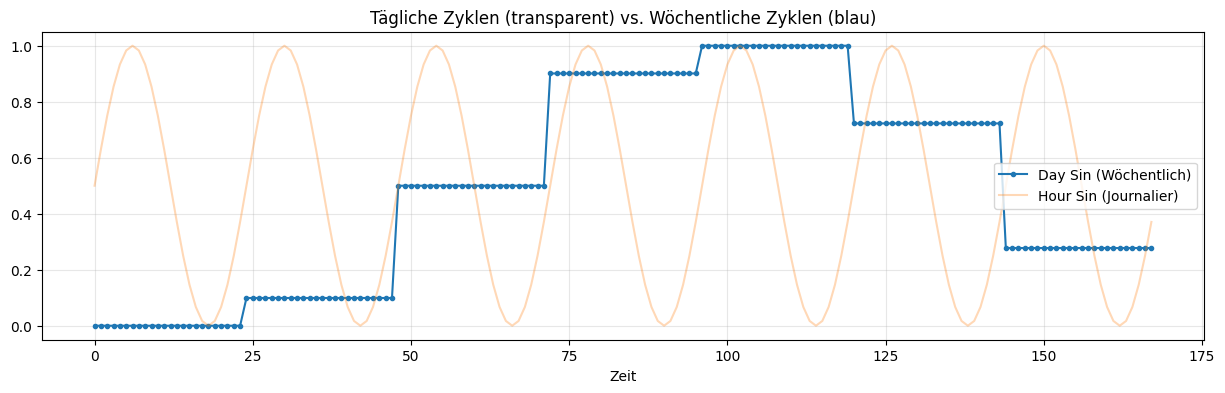

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(X_train[:168, 4], label='Day Sin (Wöchentlich)', marker='.') # 168h = 1 semaine
plt.plot(X_train[:168, 2], label='Hour Sin (Journalier)', alpha=0.3)
plt.title("Tägliche Zyklen (transparent) vs. Wöchentliche Zyklen (blau)")
plt.xlabel("Zeit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 BRANCHENANALYSE: WETTEREMPFINDLICHKEIT NACH GEBÄUDETYP


/tmp/ipython-input-274/361322786.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = analysis_df.groupby('primaryspaceusage').apply(


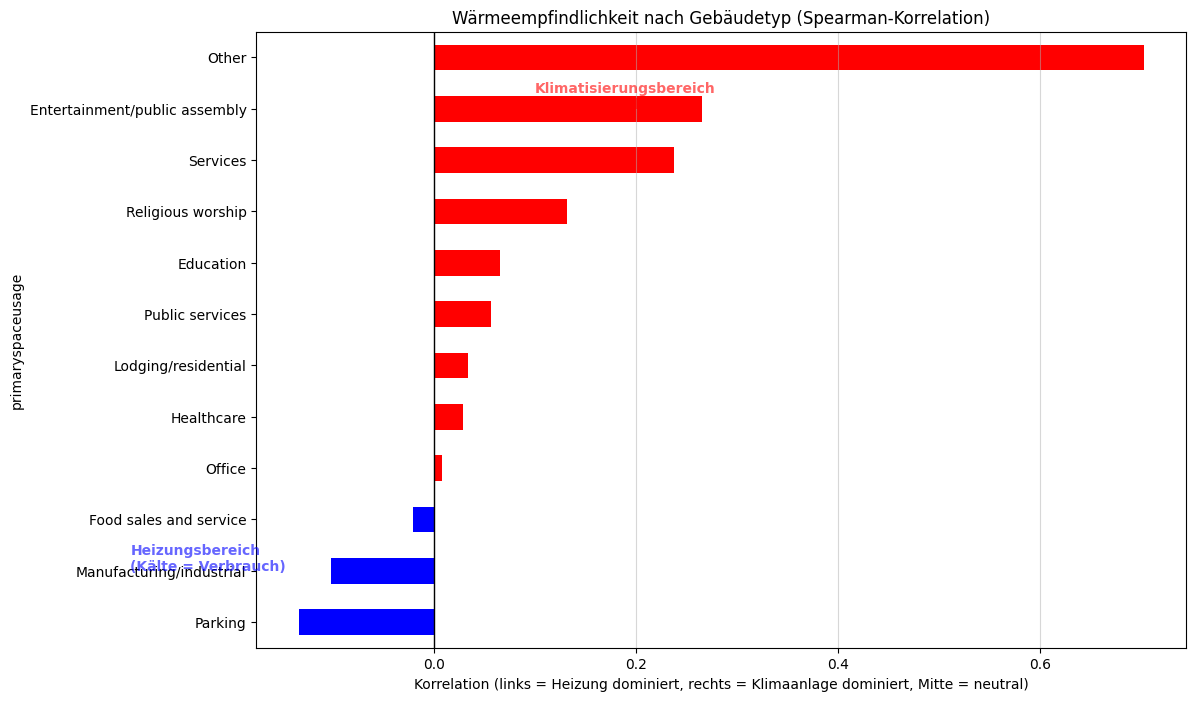

Top 3 Sensible (Heizung/Kühlung) :
primaryspaceusage
Parking                    -0.133704
Manufacturing/industrial   -0.101350
Food sales and service     -0.020766
dtype: float64

Top 3 Sensitive (Klimaanlage/Wärme) :
primaryspaceusage
Services                         0.237263
Entertainment/public assembly    0.265087
Other                            0.702722
dtype: float64

Unempfindlich (neutral) :
primaryspaceusage
Food sales and service   -0.020766
Office                    0.008537
Healthcare                0.028683
dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print(" BRANCHENANALYSE: WETTEREMPFINDLICHKEIT NACH GEBÄUDETYP")

if 'df' in locals():
    analysis_df = df[['primaryspaceusage', 'meter_reading', 'airTemperature']].dropna()
    correlations = analysis_df.groupby('primaryspaceusage').apply(
        lambda x: x['meter_reading'].corr(x['airTemperature'], method='spearman')
    ).sort_values()


    plt.figure(figsize=(12, 8))
    colors = ['red' if x > 0 else 'blue' for x in correlations]
    correlations.plot(kind='barh', color=colors)

    plt.title("Wärmeempfindlichkeit nach Gebäudetyp (Spearman-Korrelation)")
    plt.xlabel("Korrelation (links = Heizung dominiert, rechts = Klimaanlage dominiert, Mitte = neutral)")
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(axis='x', alpha=0.5)

    # Annotations explicatives
    plt.text(0.1, len(correlations)-2, "Klimatisierungsbereich\n(Warm = Verbrauch)", color='red', alpha=0.6, fontweight='bold')
    plt.text(-0.3, 1, "Heizungsbereich\n(Kälte = Verbrauch)", color='blue', alpha=0.6, fontweight='bold')

    plt.show()

    print("Top 3 Sensible (Heizung/Kühlung) :")
    print(correlations.head(3))
    print("\nTop 3 Sensitive (Klimaanlage/Wärme) :")
    print(correlations.tail(3))
    print("\nUnempfindlich (neutral) :")
    print(correlations[correlations.abs() < 0.1].head(3))

else:
    print(" Der Dataframe „df” ist nicht mehr im Speicher vorhanden.")
    print("Starten Sie den Schritt zum Laden der Daten erneut, um diese Analyse durchzuführen.")

ANALYSE DER WOCHENZYKLEN


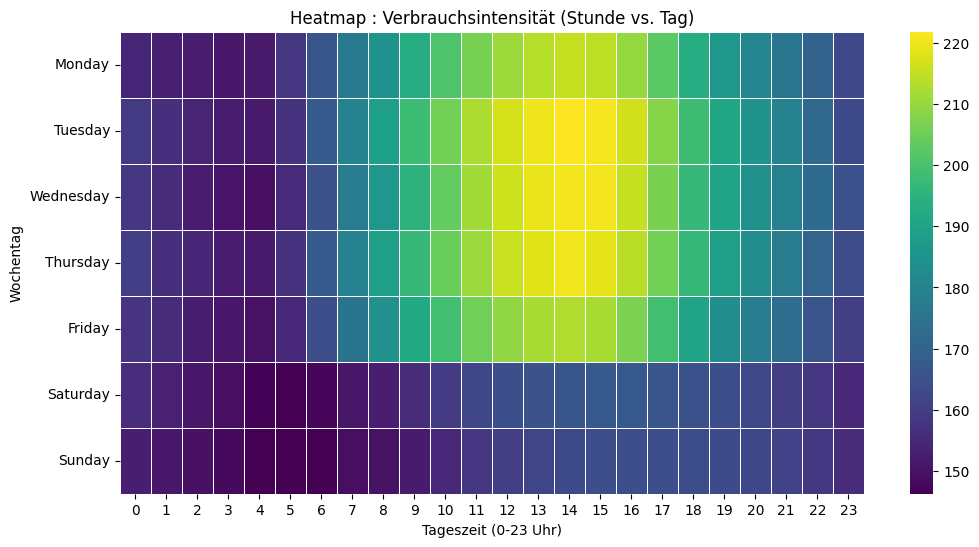

In [ ]:
import seaborn as sns

print("ANALYSE DER WOCHENZYKLEN")

df['weekday'] = df['timestamp'].dt.day_name()
df['hour'] = df['timestamp'].dt.hour


heatmap_data = df.groupby(['weekday', 'hour'])['meter_reading'].mean().unstack()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='viridis', linewidths=.5)
plt.title("Heatmap : Verbrauchsintensität (Stunde vs. Tag)")
plt.xlabel("Tageszeit (0-23 Uhr)")
plt.ylabel("Wochentag")
plt.show()

VERBRAUCHSVERTEILUNG NACH NUTZUNGSART


/tmp/ipython-input-274/1111758829.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='meter_reading', y='primaryspaceusage', order=sorted_idx, palette='viridis')


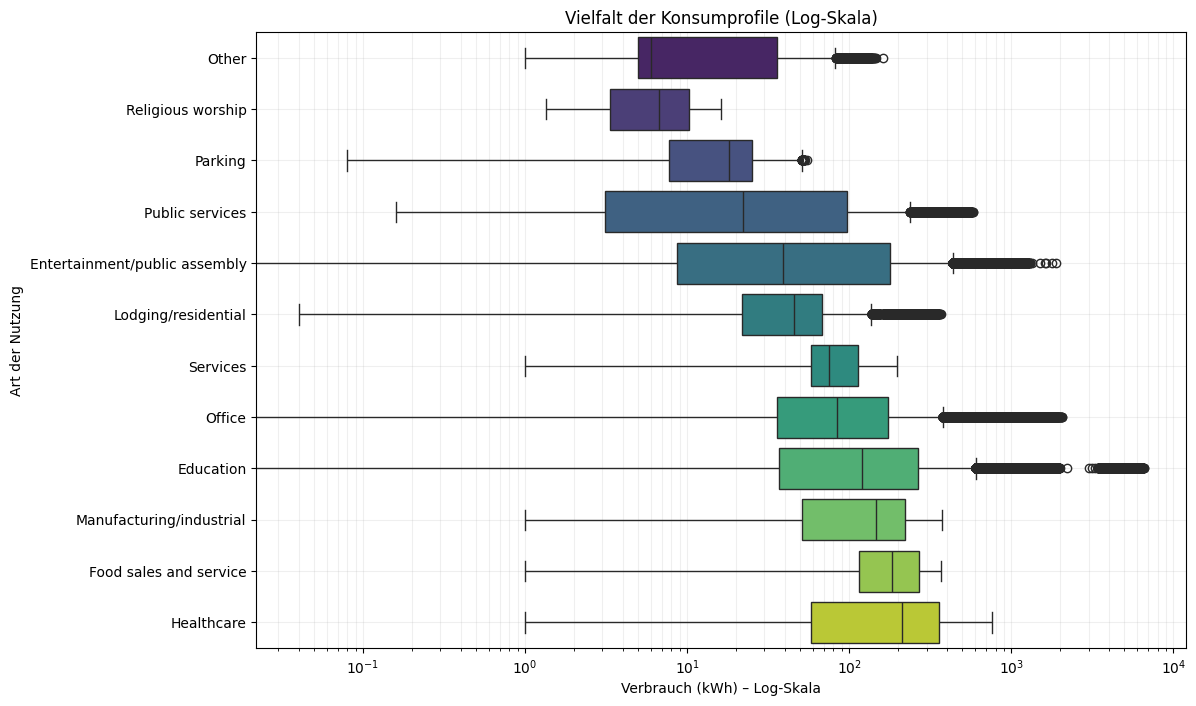

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("VERBRAUCHSVERTEILUNG NACH NUTZUNGSART")


if 'df' in locals():
    plt.figure(figsize=(12, 8))

    sorted_idx = df.groupby('primaryspaceusage')['meter_reading'].median().sort_values().index

    sns.boxplot(data=df, x='meter_reading', y='primaryspaceusage', order=sorted_idx, palette='viridis')

    plt.xscale('log')

    plt.title("Vielfalt der Konsumprofile (Log-Skala)")
    plt.xlabel("Verbrauch (kWh) – Log-Skala")
    plt.ylabel("Art der Nutzung")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()


else:
    print("Starten Sie das Laden der Daten erneut (Schritt 1), um „df” zu erhalten..")

-Start Der ISOLATION FOREST -
Training auf 272094 Datenpunkte.
Trainiertes Modell.
Berechnung der Vorhersagen für das Test-Set.

ERGEBNISSE DER ISOLATION FOREST (Baseline)
F1-Score  : 0.1148
Precision : 0.0782
Recall    : 0.2161 
--------------------------------------------------

Klassifizierungsbericht :
              precision    recall  f1-score   support

      Normal       0.98      0.93      0.95     66280
    Anomalie       0.08      0.22      0.11      1749

    accuracy                           0.91     68029
   macro avg       0.53      0.57      0.53     68029
weighted avg       0.96      0.91      0.93     68029



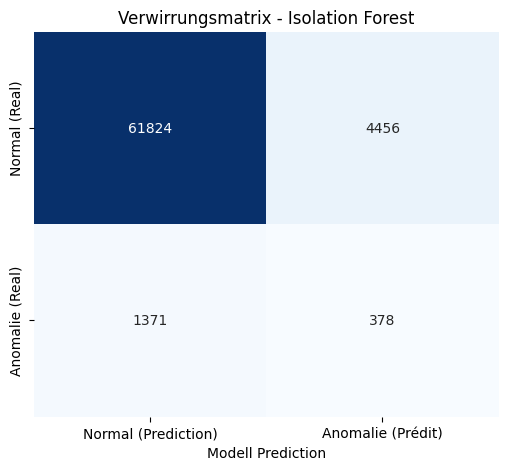

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

print("-Start Der ISOLATION FOREST -")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.025,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print(f"Training auf {X_train.shape[0]} Datenpunkte.")
iso_forest.fit(X_train)
print("Trainiertes Modell.")
print("Berechnung der Vorhersagen für das Test-Set.")

y_pred_raw = iso_forest.predict(X_test)
y_pred_binary = [1 if x == -1 else 0 for x in y_pred_raw]

print("\n" + "="*50)
print("ERGEBNISSE DER ISOLATION FOREST (Baseline)")
print("="*50)

f1 = f1_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)

print(f"F1-Score  : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f} ")
print("-" * 50)

print("\nKlassifizierungsbericht :")
print(classification_report(y_test, y_pred_binary, target_names=['Normal', 'Anomalie']))

cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (Prediction)', 'Anomalie (Prédit)'],
            yticklabels=['Normal (Real)', 'Anomalie (Real)'])
plt.title("Verwirrungsmatrix - Isolation Forest")
plt.ylabel("")
plt.xlabel("Modell Prediction")
plt.show()

- TRENNUNG VON INTACTEN DATEN (CLEAN TRAINING) -
Gesamt Train : 272094
Clean Train (Normal Only) : 267531
Das Modell wird während des Trainings KEINE Anomalien feststellen..

Erstellung der Sequenzen.
Shape Train (Clean) : (267507, 24, 10)
Shape Test (All)    : (68005, 24, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



- START TRAINING (Clean Data) -
Epoch 1/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 0.0246 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 2/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - loss: 0.0065 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 3/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - loss: 0.0049 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.0043 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 5/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.0040 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 6/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - loss: 0.0038 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 7/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 0.0036 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 8/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.0034 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 9/20
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step

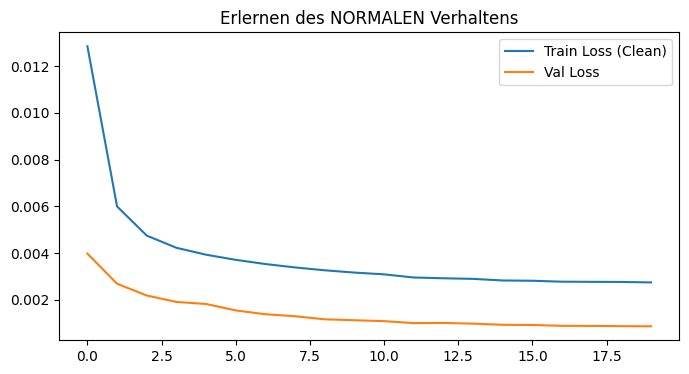

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


print("- TRENNUNG VON INTACTEN DATEN (CLEAN TRAINING) -")

train_normal_indices = np.where(y_train == 0)[0]
X_train_normal = X_train[train_normal_indices]

print(f"Gesamt Train : {len(X_train)}")
print(f"Clean Train (Normal Only) : {len(X_train_normal)}")
print("Das Modell wird während des Trainings KEINE Anomalien feststellen..")

TIME_STEPS = 24

def create_sequences(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

print("\nErstellung der Sequenzen.")

X_train_clean_seq, _ = create_sequences(X_train_normal, np.zeros(len(X_train_normal)))
X_test_seq, y_test_seq = create_sequences(X_test, y_test)

print(f"Shape Train (Clean) : {X_train_clean_seq.shape}")
print(f"Shape Test (All)    : {X_test_seq.shape}")


model = Sequential()

model.add(Bidirectional(LSTM(64, activation='tanh', return_sequences=False),
                        input_shape=(X_train_clean_seq.shape[1], X_train_clean_seq.shape[2])))
model.add(Dropout(0.2))
model.add(RepeatVector(X_train_clean_seq.shape[1]))
model.add(Bidirectional(LSTM(64, activation='tanh', return_sequences=True)))
model.add(Dropout(0.2))
model.add(TimeDistributed(Dense(X_train_clean_seq.shape[2])))

model.compile(optimizer='adam', loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=4, mode='min', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)

print("\n- START TRAINING (Clean Data) -")
history = model.fit(
    X_train_clean_seq, X_train_clean_seq,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss (Clean)')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Erlernen des NORMALEN Verhaltens")
plt.legend()
plt.show()

- BERECHNUNG DER REKONSTRUKTIONSFEHLER -
8360/8360 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
Mittlerer Fehler Train (Clean) : 0.01618
Mittlerer Fehler Test (Mixed)  : 0.02912

- SCHWELLENWERTOPTIMIERUNG (FINALE) -

 ENDERGEBNIS DES DEEP LEARNING :
   Bestes Perzentil : 96.76%
   Beste Schwelle      : 0.03886
   F1-SCORE RECORD     : 0.1526
------------------------------
   Baseline (IsoForest) : 0.1148
 Das LSTM schlägt den Isolation Forest von +3.78 points !


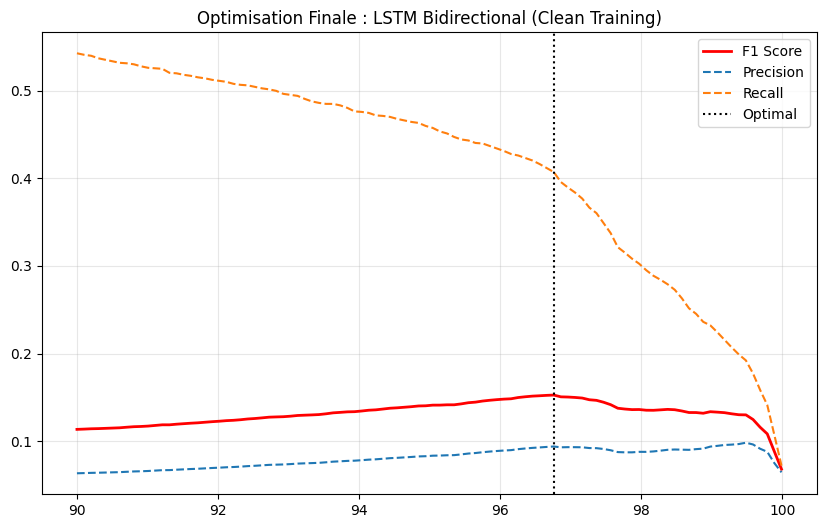

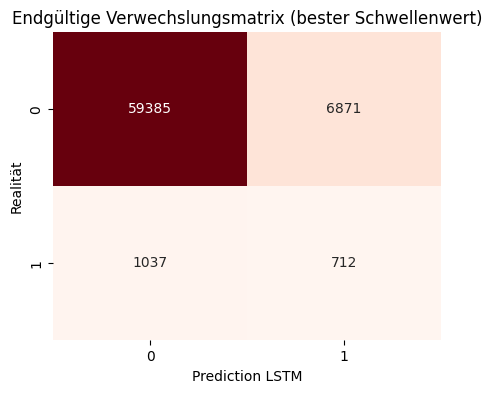

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score


print("- BERECHNUNG DER REKONSTRUKTIONSFEHLER -")

X_train_clean_pred = model.predict(X_train_clean_seq)
X_test_pred = model.predict(X_test_seq)

train_mae_loss = np.mean(np.mean(np.abs(X_train_clean_pred - X_train_clean_seq), axis=1), axis=1)
test_mae_loss = np.mean(np.mean(np.abs(X_test_pred - X_test_seq), axis=1), axis=1)

print(f"Mittlerer Fehler Train (Clean) : {np.mean(train_mae_loss):.5f}")
print(f"Mittlerer Fehler Test (Mixed)  : {np.mean(test_mae_loss):.5f}")


print("\n- SCHWELLENWERTOPTIMIERUNG (FINALE) -")

thresholds_candidates = np.linspace(90, 99.99, 100)
f1_scores = []
precisions = []
recalls = []

best_f1 = 0
best_thresh = 0
best_p = 0

for p in thresholds_candidates:
    thresh = np.percentile(train_mae_loss, p)

    y_pred = [1 if e > thresh else 0 for e in test_mae_loss]

    score = f1_score(y_test_seq, y_pred, zero_division=0)
    f1_scores.append(score)
    precisions.append(precision_score(y_test_seq, y_pred, zero_division=0))
    recalls.append(recall_score(y_test_seq, y_pred, zero_division=0))

    if score > best_f1:
        best_f1 = score
        best_thresh = thresh
        best_p = p

print(f"\n ENDERGEBNIS DES DEEP LEARNING :")
print(f"   Bestes Perzentil : {best_p:.2f}%")
print(f"   Beste Schwelle      : {best_thresh:.5f}")
print(f"   F1-SCORE RECORD     : {best_f1:.4f}")
print("-" * 30)

baseline_f1 = 0.1148
print(f"   Baseline (IsoForest) : {baseline_f1}")
if best_f1 > baseline_f1:
    print(f" Das LSTM schlägt den Isolation Forest von +{(best_f1 - baseline_f1)*100:.2f} points !")
else:
    print(f"  Das LSTM erreicht seine Sättigungsgrenze (ähnliche Leistungen).")


# Graphique Final
plt.figure(figsize=(10, 6))
plt.plot(thresholds_candidates, f1_scores, label='F1 Score', color='red', linewidth=2)
plt.plot(thresholds_candidates, precisions, label='Precision', linestyle='--')
plt.plot(thresholds_candidates, recalls, label='Recall', linestyle='--')
plt.axvline(best_p, color='black', linestyle=':', label='Optimal')
plt.title("Optimisation Finale : LSTM Bidirectional (Clean Training)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

y_best_pred = [1 if e > best_thresh else 0 for e in test_mae_loss]
cm = confusion_matrix(y_test_seq, y_best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title("Endgültige Verwechslungsmatrix (bester Schwellenwert)")
plt.ylabel("Realität")
plt.xlabel("Prediction LSTM")
plt.show()

- Suche nach dem optimalen Schwellenwert (Maximierung des F1-Werts)-

BESTES GEFUNDENES ERGEBNIS :
   Optimales Perzentil : 96.67
   Schwellenwert    : 0.0385
   Maximaler F1-Score   : 0.1524


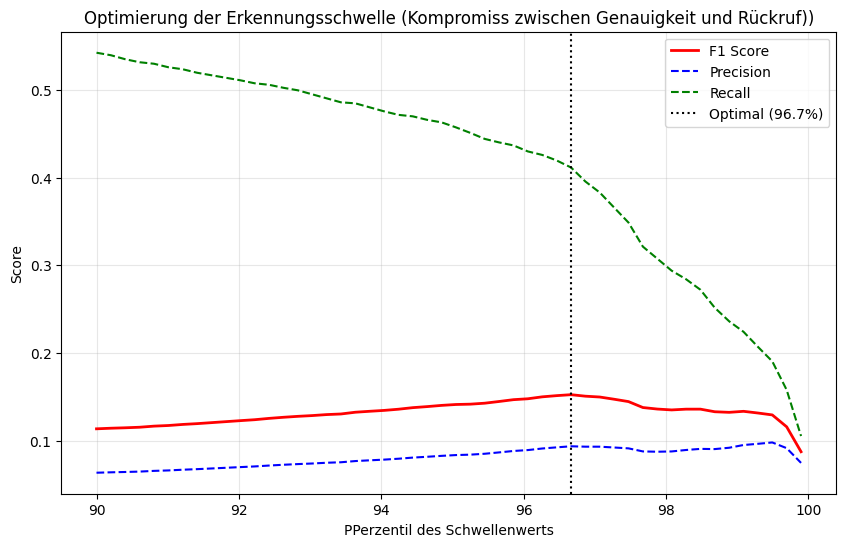


ENDGÜLTIGER VERGLEICH (BASELINE VS. OPTIMIERTES LSTM)
Isolation Forest (Baseline) -> F1: ~0.1148 | Recall: ~0.22
LSTM Autoencoder (Optimiert) -> F1: 0.1524  | Recall: (Siehe Kurve)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score


print("- Suche nach dem optimalen Schwellenwert (Maximierung des F1-Werts)-")

thresholds_candidates = np.linspace(90, 99.9, 50)
f1_scores = []
precisions = []
recalls = []

best_f1 = 0
best_threshold_val = 0
best_percentile = 0

for p in thresholds_candidates:

    thresh_val = np.percentile(train_mae_loss, p)
    y_pred_temp = [1 if e > thresh_val else 0 for e in test_mae_loss]
    f1 = f1_score(y_test_seq, y_pred_temp)
    prec = precision_score(y_test_seq, y_pred_temp, zero_division=0)
    rec = recall_score(y_test_seq, y_pred_temp, zero_division=0)

    f1_scores.append(f1)
    precisions.append(prec)
    recalls.append(rec)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold_val = thresh_val
        best_percentile = p

print(f"\nBESTES GEFUNDENES ERGEBNIS :")
print(f"   Optimales Perzentil : {best_percentile:.2f}")
print(f"   Schwellenwert    : {best_threshold_val:.4f}")
print(f"   Maximaler F1-Score   : {best_f1:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds_candidates, f1_scores, label='F1 Score', color='red', linewidth=2)
plt.plot(thresholds_candidates, precisions, label='Precision', color='blue', linestyle='--')
plt.plot(thresholds_candidates, recalls, label='Recall', color='green', linestyle='--')
plt.axvline(best_percentile, color='black', linestyle=':', label=f'Optimal ({best_percentile:.1f}%)')

plt.title("Optimierung der Erkennungsschwelle (Kompromiss zwischen Genauigkeit und Rückruf))")
plt.xlabel("PPerzentil des Schwellenwerts")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*50)
print(f"ENDGÜLTIGER VERGLEICH (BASELINE VS. OPTIMIERTES LSTM)")
print("="*50)
print(f"Isolation Forest (Baseline) -> F1: ~0.1148 | Recall: ~0.22")
print(f"LSTM Autoencoder (Optimiert) -> F1: {best_f1:.4f}  | Recall: (Siehe Kurve)")

--- ANALYSE VISUELLE DES TYPES D'ANOMALIES ---
Verwendung des ermittelten optimalen Schwellenwerts : 0.0389

 Anzahl der echten Positive (Erfolg des Modells) : 712
 Anzahl der falsch-negativen Ergebnisse  (übersehene Anomalien) : 1037

Erstellung von ECHT POSITIVEN Grafiken.


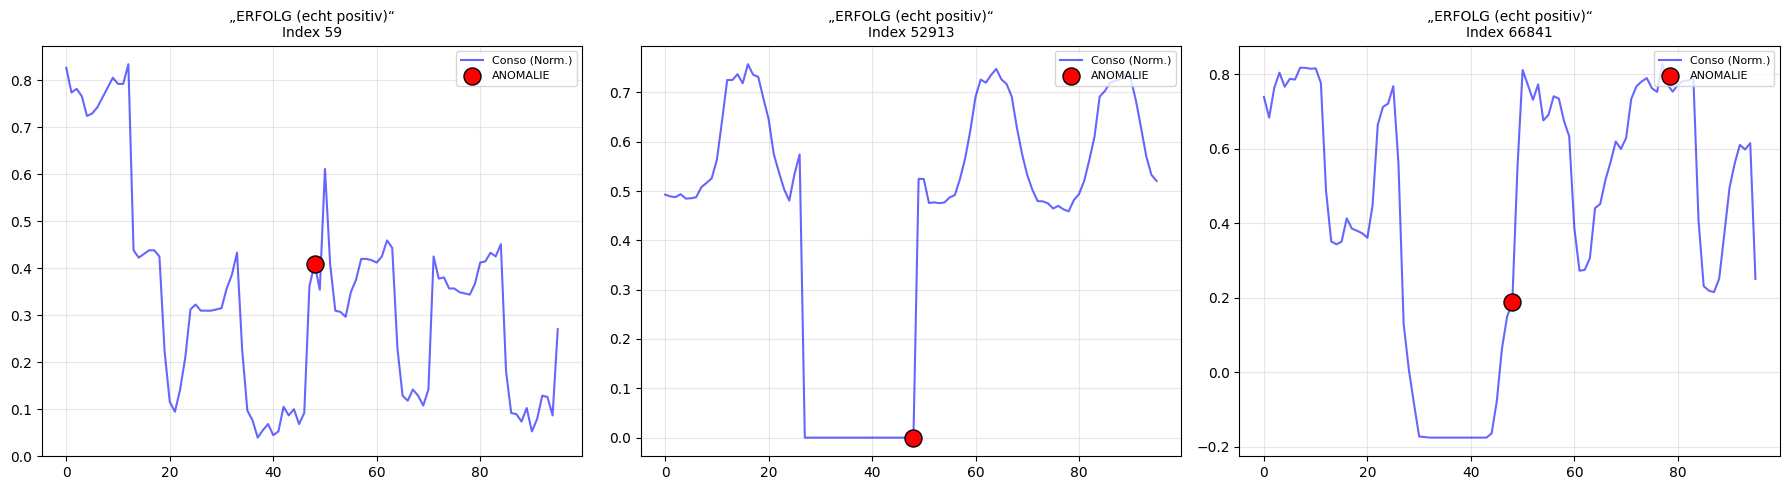


Erstellung von Falsch-Negativ-Diagrammen.


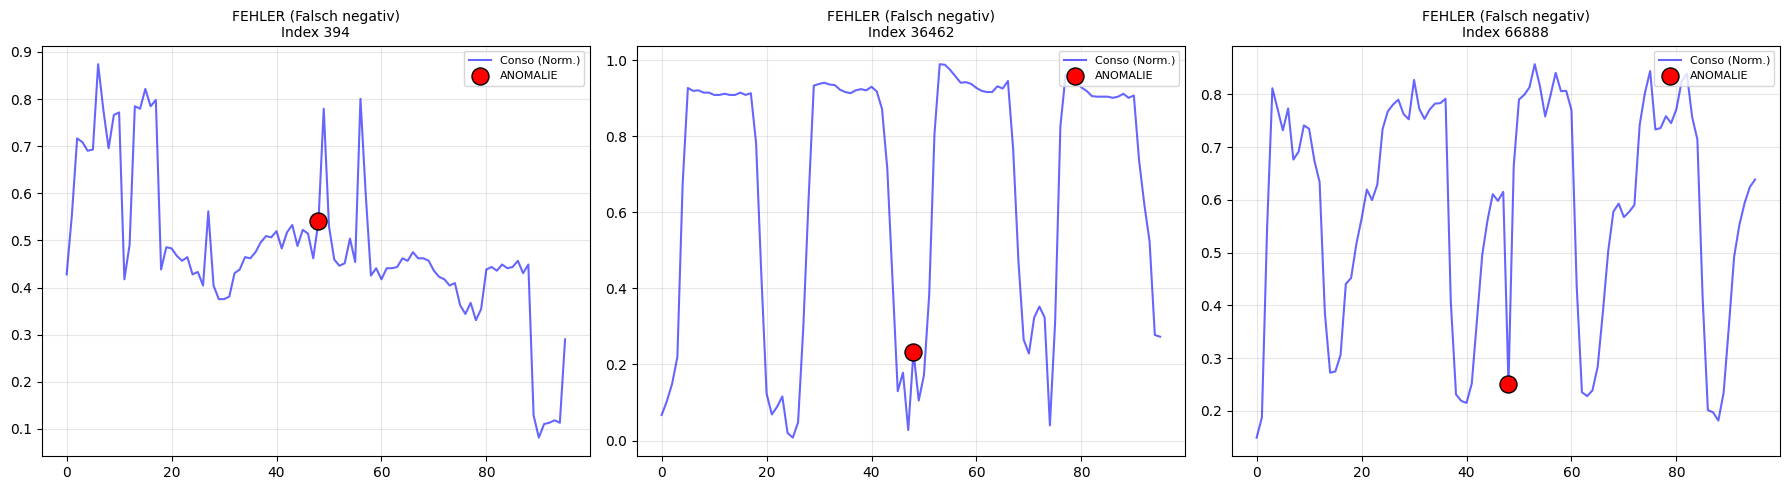

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


print("--- ANALYSE VISUELLE DES TYPES D'ANOMALIES ---")
y_true = np.array(y_test_seq)

if 'best_thresh' in locals():
    print(f"Verwendung des ermittelten optimalen Schwellenwerts : {best_thresh:.4f}")
    y_pred = np.array([1 if e > best_thresh else 0 for e in test_mae_loss])
else:
    print("Variable „best_thresh” nicht gefunden, Verwendung eines Ersatzschwellenwerts (96,7 %).")

    fallback_thresh = np.percentile(train_mae_loss, 96.76)
    y_pred = np.array([1 if e > fallback_thresh else 0 for e in test_mae_loss])

true_positives = np.where((y_true == 1) & (y_pred == 1))[0]
false_negatives = np.where((y_true == 1) & (y_pred == 0))[0]

print(f"\n Anzahl der echten Positive (Erfolg des Modells) : {len(true_positives)}")
print(f" Anzahl der falsch-negativen Ergebnisse  (übersehene Anomalien) : {len(false_negatives)}")

def plot_anomaly_zoom(idx, title_prefix, ax):

    target_pos = idx + 24

    plot_start = max(0, idx - 48)
    plot_end = min(len(y_test_seq), idx + 48)

    data_chunk = []
    indices_range = range(plot_start, plot_end)
    vals = X_test_seq[indices_range, -1, 0]

    ax.plot(range(len(vals)), vals, label='Conso (Norm.)', color='blue', alpha=0.6)

    anomaly_rel_idx = idx - plot_start

    ax.scatter(anomaly_rel_idx, vals[anomaly_rel_idx], color='red', s=150, label='ANOMALIE', zorder=5, edgecolors='black')

    ax.set_title(f"{title_prefix}\nIndex {idx}", fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

if len(true_positives) > 0:
    print("\nErstellung von ECHT POSITIVEN Grafiken.")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sample_indices = np.linspace(0, len(true_positives)-1, 3, dtype=int)

    for i, list_idx in enumerate(sample_indices):
        real_idx = true_positives[list_idx]
        plot_anomaly_zoom(real_idx, "„ERFOLG (echt positiv)“", axes[i])
    plt.tight_layout()
    plt.show()

if len(false_negatives) > 0:
    print("\nErstellung von Falsch-Negativ-Diagrammen.")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sample_indices = np.linspace(0, len(false_negatives)-1, 3, dtype=int)

    for i, list_idx in enumerate(sample_indices):
        real_idx = false_negatives[list_idx]
        plot_anomaly_zoom(real_idx, "FEHLER (Falsch negativ)", axes[i])
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import gc

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def create_sequences_vectorized(X, y, time_steps=24):

    print(" Vektorisierung läuft.")

    X_windows = sliding_window_view(X, window_shape=time_steps, axis=0)
    X_seq = np.moveaxis(X_windows, -1, 1)
    y_seq = y[time_steps:]
    X_seq = X_seq[:len(y_seq)]

    return X_seq.astype('float32'), y_seq.astype('int')

try:

    TIME_STEPS = 24

    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')

    print("\nGeneration Train...")
    X_train_seq, y_train_seq = create_sequences_vectorized(X_train, y_train, TIME_STEPS)

    print("\nGeneration Test...")
    X_test_seq, y_test_seq = create_sequences_vectorized(X_test, y_test, TIME_STEPS)

    gc.collect()

    print(f"\nGenerierte Sequenzen :")
    print(f"   Train : {X_train_seq.shape} | {X_train_seq.nbytes / 1e6:.1f} MB")
    print(f"   Test  : {X_test_seq.shape}  | {X_test_seq.nbytes / 1e6:.1f} MB")


    print("\nErstellung des Modells...")
    n_timesteps = X_train_seq.shape[1]
    n_features = X_train_seq.shape[2]

    model = Sequential([

        LSTM(64, activation='tanh', input_shape=(n_timesteps, n_features), return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=False),

        RepeatVector(n_timesteps),

        LSTM(32, activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='tanh', return_sequences=True),

        TimeDistributed(Dense(n_features))
    ])

    model.compile(optimizer='adam', loss='mse')


    BATCH_SIZE = 64
    EPOCHS = 15

    print(f"Training Starten.")

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_seq, X_train_seq,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    print(" Modell eingearbeitet und einsatzbereit.")

except NameError:
    print("FEHLER: Die Variablen X_train/X_test existieren nicht.")
except Exception as e:
    print(f"FEHLER : {e}")

    print("\nBerechnung der Punktzahlen.")

    X_train_pred = model.predict(X_train_seq, batch_size=256, verbose=0)
    X_test_pred = model.predict(X_test_seq, batch_size=256, verbose=0)
    train_mae_loss = np.mean(np.abs(X_train_pred - X_train_seq), axis=(1, 2))
    test_mae_loss = np.mean(np.abs(X_test_pred - X_test_seq), axis=(1, 2))
    THRESHOLD = np.percentile(train_mae_loss, 98)
    print(f" Definierte Schwelle : {THRESHOLD:.4f}")

    y_pred_lstm = test_mae_loss > THRESHOLD
    y_pred_lstm = y_pred_lstm.astype(int)


    print("\n" + "="*40)
    print(" LSTM ERGEBNISSE")
    print("="*40)
    print(classification_report(y_test_seq, y_pred_lstm, target_names=['Normal', 'Anomalie']))

    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title("Lernkurve")
    plt.legend()
    plt.show()


    plt.figure(figsize=(10, 4))
    sns.histplot(test_mae_loss, bins=50, kde=True, color='green')
    plt.axvline(THRESHOLD, color='red', linestyle='--', label='Seuil')
    plt.title("Fehlerverteilung")
    plt.show()

except NameError:
    print("FEHLER: Die Variablen X_train/X_test existieren nicht." )
except Exception as e:
    print(f"FEHLER: {e}")


Generation Train...
 Vektorisierung läuft.

Generation Test...
 Vektorisierung läuft.

Generierte Sequenzen :
   Train : (272070, 24, 10) | 261.2 MB
   Test  : (68005, 24, 10)  | 65.3 MB

Erstellung des Modells...
Training Starten.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 59s 14ms/step - loss: 0.0264 - val_loss: 0.0042
Epoch 2/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - loss: 0.0043 - val_loss: 0.0029
Epoch 3/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 4/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 0.0026 - val_loss: 0.0019
Epoch 5/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 58s 15ms/step - loss: 0.0023 - val_loss: 0.0017
Epoch 6/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 7/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 8/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 9/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 85s 16ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 10/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 11/15
3826/3826 ━━━━━━━━━━━━━━━━━━━━ 58s 15ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 12


= Ergebniss=
(Point)      -> IF: 100.0%   | LSTM: 100.0%
(Context)  -> IF: 18.0%   | LSTM: 84.5%
(Collect)-> IF: 7.5%    | LSTM: 55.5%


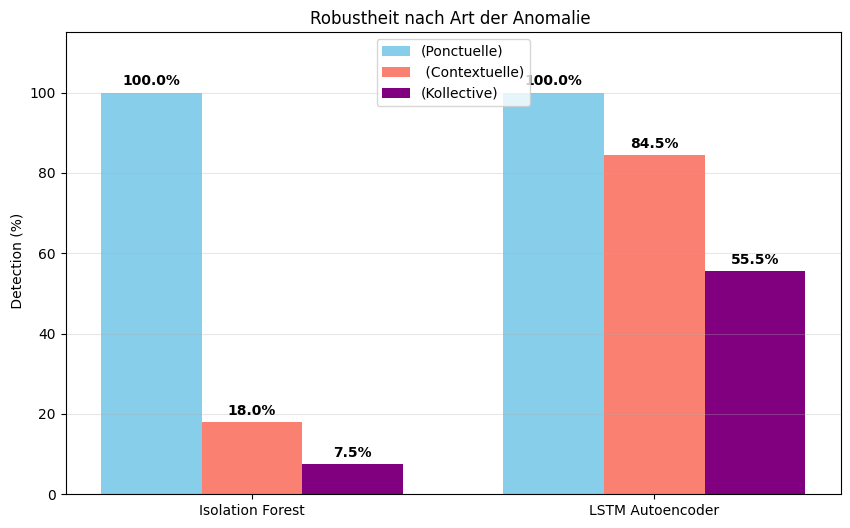

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


n_samples = 200

indices = np.random.choice(len(X_train_clean_seq), n_samples, replace=False)
clean_samples = X_train_clean_seq[indices].copy()

lstm_threshold = best_thresh

scores = {
    "IF_Point": 0, "LSTM_Point": 0,
    "IF_Context": 0, "LSTM_Context": 0,
    "IF_Collective": 0, "LSTM_Collective": 0
}


def update_features_consistency(seq, idx_impacted):

    val = seq[idx_impacted, 0]
    old_mean = seq[idx_impacted, 8]
    new_mean = (5 * old_mean + val) / 6
    seq[idx_impacted, 8] = new_mean
    seq[idx_impacted, 9] = 1.0

    return seq

for i in range(n_samples):

    original_seq = clean_samples[i].copy()
    spike_seq = original_seq.copy()
    spike_val = 5.0

    spike_seq[12, 0] = spike_val
    spike_seq = update_features_consistency(spike_seq, 12)

    reconstr = model.predict(spike_seq.reshape(1, 24, 10), verbose=0)
    if np.mean(np.mean(np.abs(spike_seq - reconstr), axis=1)) > lstm_threshold:
        scores["LSTM_Point"] += 1

    point_vector = spike_seq[12, :].reshape(1, -1)
    if iso_forest.predict(point_vector)[0] == -1:
        scores["IF_Point"] += 1

    flat_seq = original_seq.copy()
    flat_seq[:, 0] = 0.0
    flat_seq[:, 8] = 0.0
    flat_seq[:, 9] = 0.0

    reconstr = model.predict(flat_seq.reshape(1, 24, 10), verbose=0)
    if np.mean(np.mean(np.abs(flat_seq - reconstr), axis=1)) > lstm_threshold:
        scores["LSTM_Context"] += 1

    if -1 in iso_forest.predict(flat_seq):
        scores["IF_Context"] += 1

    pattern_seq = original_seq.copy()
    noise = np.random.uniform(0.2, 0.6, size=24)
    pattern_seq[:, 0] = noise

    reconstr = model.predict(pattern_seq.reshape(1, 24, 10), verbose=0)
    if np.mean(np.mean(np.abs(pattern_seq - reconstr), axis=1)) > lstm_threshold:
        scores["LSTM_Collective"] += 1

    if -1 in iso_forest.predict(pattern_seq):
        scores["IF_Collective"] += 1

p_point_if = (scores['IF_Point'] / n_samples) * 100
p_point_lstm = (scores['LSTM_Point'] / n_samples) * 100

p_context_if = (scores['IF_Context'] / n_samples) * 100
p_context_lstm = (scores['LSTM_Context'] / n_samples) * 100

p_collect_if = (scores['IF_Collective'] / n_samples) * 100
p_collect_lstm = (scores['LSTM_Collective'] / n_samples) * 100

print("\n= Ergebniss=")
print(f"(Point)      -> IF: {p_point_if:.1f}%   | LSTM: {p_point_lstm:.1f}%")
print(f"(Context)  -> IF: {p_context_if:.1f}%   | LSTM: {p_context_lstm:.1f}%")
print(f"(Collect)-> IF: {p_collect_if:.1f}%    | LSTM: {p_collect_lstm:.1f}%")

labels = ['Isolation Forest', 'LSTM Autoencoder']
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, [p_point_if, p_point_lstm], width, label='(Ponctuelle)', color='skyblue')
rects2 = ax.bar(x, [p_context_if, p_context_lstm], width, label=' (Contextuelle)', color='salmon')
rects3 = ax.bar(x + width, [p_collect_if, p_collect_lstm], width, label='(Kollective)', color='purple')

ax.set_ylabel(' Detection (%)')
ax.set_title('Robustheit nach Art der Anomalie ')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper center')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.show()


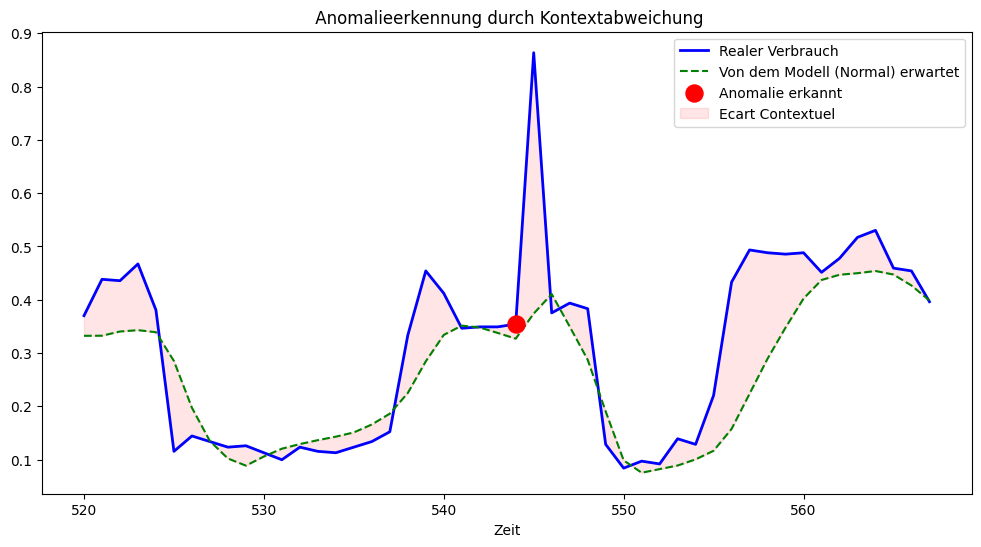

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


safe_threshold = np.percentile(train_mae_loss, 92)
y_pred_lstm = (test_mae_loss > safe_threshold).astype(int)
tp_indices = np.where((y_test_seq == 1) & (y_pred_lstm == 1))[0]

if len(tp_indices) > 0:

    idx = tp_indices[min(10, len(tp_indices)-1)]

    plt.figure(figsize=(12, 6))
    start = max(0, idx - 24)
    end = min(len(y_test_seq), idx + 24)
    plt.plot(range(start, end), X_test_seq[start:end, -1, 0], 'b-', label='Realer Verbrauch', linewidth=2)

    plt.plot(range(start, end), X_test_pred[start:end, -1, 0], 'g--', label='Von dem Modell (Normal) erwartet')

    plt.scatter(idx, X_test_seq[idx, -1, 0], color='red', s=150, label='Anomalie erkannt', zorder=5)

    plt.fill_between(range(start, end), X_test_seq[start:end, -1, 0], X_test_pred[start:end, -1, 0], color='red', alpha=0.1, label="Ecart Contextuel")

    plt.title(f" Anomalieerkennung durch Kontextabweichung")
    plt.xlabel("Zeit")
    plt.legend()
    plt.show()

else:
    print(" Keine Anomalien bei diesem Schwellenwert festgestellt .")

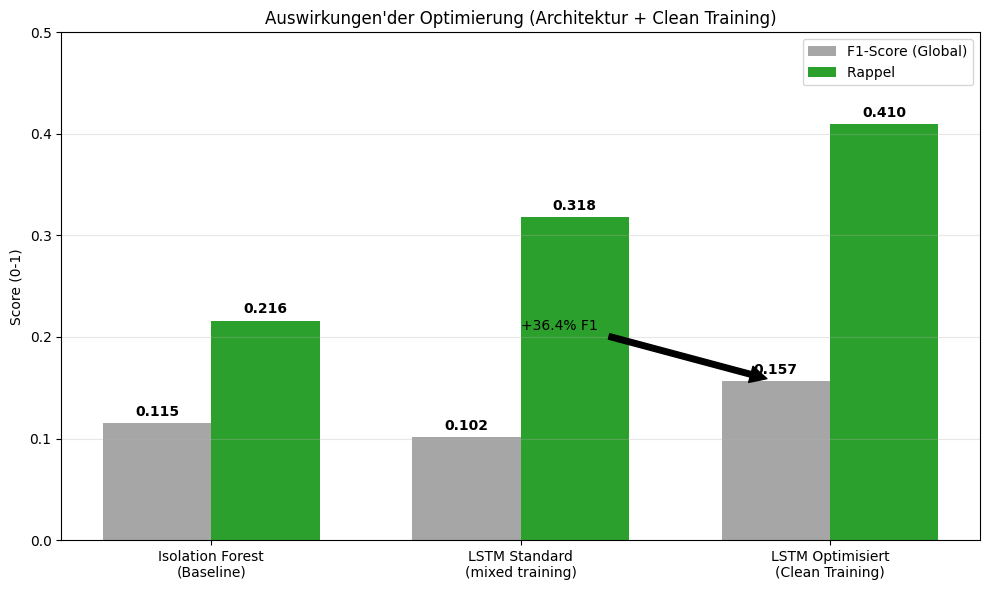

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = ['Isolation Forest\n(Baseline)', 'LSTM Standard\n(mixed training)', 'LSTM Optimisiert\n(Clean Training)']
f1_scores = [0.1148, 0.1015, 0.1566]
recalls =   [0.2161, 0.3179, 0.4100]

gain_f1 = ((f1_scores[2] - f1_scores[0]) / f1_scores[0]) * 100
gain_recall = ((recalls[2] - recalls[0]) / recalls[0]) * 100
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score (Global)', color='gray', alpha=0.7)
rects2 = ax.bar(x + width/2, recalls, width, label='Rappel ', color='#2ca02c') # Vert

ax.set_ylabel('Score (0-1)')
ax.set_title('Auswirkungen\'der Optimierung (Architektur + Clean Training)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 0.5)
ax.grid(axis='y', alpha=0.3)

def autolabel(rects, is_percentage=False):
    for rect in rects:
        height = rect.get_height()
        label = f"{height:.1f}%" if is_percentage else f"{height:.3f}"
        ax.annotate(label,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

ax.annotate(f'+{gain_f1:.1f}% F1',
            xy=(2 - width/2, f1_scores[2]),
            xytext=(1, f1_scores[2] + 0.05),
            arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()